### 02. 분류

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

#### 2-1. 로지스틱 회귀
이진 분류

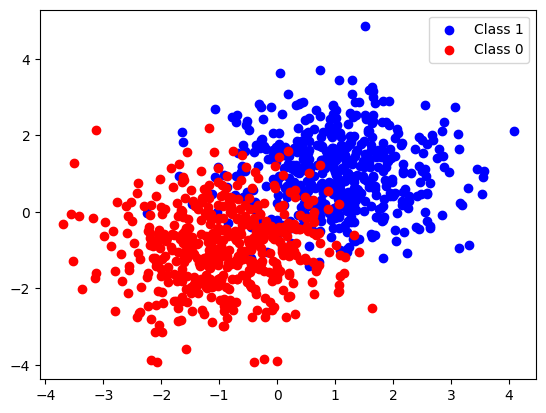

Epoch [100 / 1500], Loss:  0.3015
Epoch [200 / 1500], Loss:  0.2762
Epoch [300 / 1500], Loss:  0.2594
Epoch [400 / 1500], Loss:  0.2475
Epoch [500 / 1500], Loss:  0.2386
Epoch [600 / 1500], Loss:  0.2317
Epoch [700 / 1500], Loss:  0.2262
Epoch [800 / 1500], Loss:  0.2218
Epoch [900 / 1500], Loss:  0.2181
Epoch [1000 / 1500], Loss:  0.2150
Epoch [1100 / 1500], Loss:  0.2124
Epoch [1200 / 1500], Loss:  0.2102
Epoch [1300 / 1500], Loss:  0.2083
Epoch [1400 / 1500], Loss:  0.2066
Epoch [1500 / 1500], Loss:  0.2051


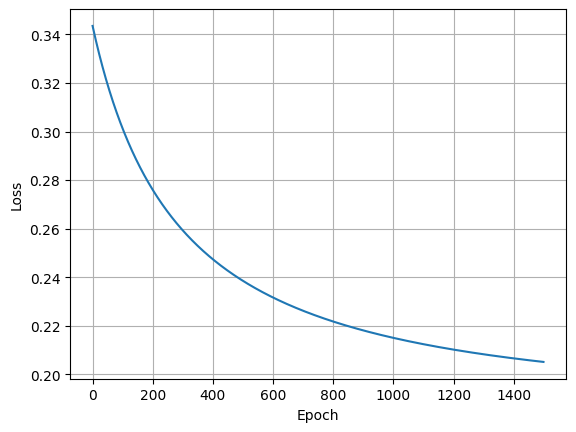

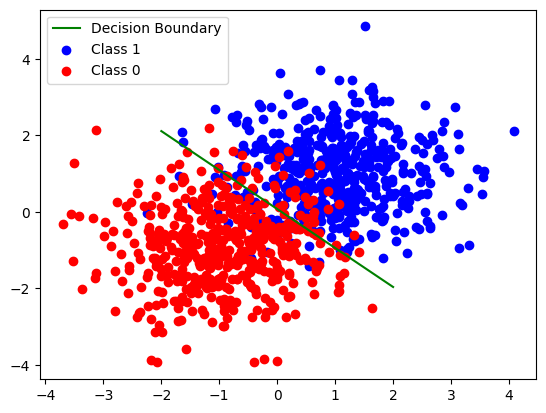

In [9]:
# 1. 데이터 입출력 정의
np.random.seed(42) # 시드 고정
num_samples = 1000

# 가우시안 샘플 생성
# 평균이 (1,1)인 2D 정규분포
mean_1 = np.array([1., 1.])
cov_1 = np.array([[1,0], [0,1]])
data_1 = np.random.multivariate_normal(mean_1, cov_1, num_samples // 2)

mean_2 = np.array([-1., -1.])
cov_2 = np.array([[1,0], [0,1]])
data_2 = np.random.multivariate_normal(mean_2, cov_2, num_samples // 2)

# 데이터 확인
plt.scatter(data_1[:, 0], data_1[:,1], color="b", label="Class 1")
plt.scatter(data_2[:, 0], data_2[:,1], color="r", label="Class 0")
plt.legend()
plt.show()

# 데이터 정의 및 텐서로 변환
data = np.vstack((data_1, data_2))
labels = np.ones(num_samples)
labels[num_samples // 2: ] = 0

data = torch.from_numpy(data).float()
labels = torch.from_numpy(labels).float()
labels = labels.view(-1, 1)
num_samples, num_features = data.shape

# 2. 모델 정의
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.linear(x)
        out = self.sigmoid(out)
        return out
    
model = LogisticRegression(2, 1)

# 3. 손실함수 정의
criterion = nn.BCELoss()

# 4. 가중치 업데이트 (학습)
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
epochs = 1500
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1} / {epochs}], Loss: {loss.item(): .4f}")

# 5. 시각화
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# 결정 경계 그리기
w = model.linear.weight.detach().cpu().numpy()
b = model.linear.bias.detach().cpu().numpy()
x_plot = np.array([-2, 2])
y_plot = (-b -w[0][0] * x_plot) / w[0][1]
plt.plot(x_plot, y_plot, color = 'g', label="Decision Boundary")
plt.scatter(data_1[:, 0], data_1[:,1], color="b", label="Class 1")
plt.scatter(data_2[:, 0], data_2[:,1], color="r", label="Class 0")
plt.legend()
plt.show()